In [1]:
# importation des librairies à utiliser
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cmocean
import cartopy.feature as cfeature
import pandas as pd
from cartopy.mpl.patch import geos_to_path
import matplotlib.patches as mpatches

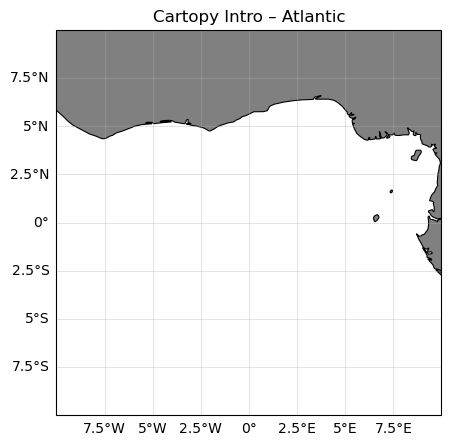

In [2]:
# Délimitation de la zone d'étude
proj = ccrs.PlateCarree()
plt.figure(figsize=(8,5))
ax = plt.axes(projection=proj)
extent = [-10, 10, -10, 10]# [-70, 20, -30, 30]
ax.set_extent(extent, crs=proj)
ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.5")
ax.coastlines(resolution='50m', linewidth=0.8)
# gl = ax.gridlines(draw_labels=True)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
plt.title("Cartopy Intro – Atlantic")
plt.show()

In [3]:
# importation des données téléchargées 
nc_ssh = xr.open_dataset(
    "C:\\Users\\fotso tagne\\Desktop\\GGOSSS_2025\\cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_1756287022385.nc"
)
nc_ssh

<xarray.Dataset> Size: 70MB
Dimensions:    (time: 365, latitude: 80, longitude: 100)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * latitude   (latitude) float32 320B -9.875 -9.625 -9.375 ... 9.625 9.875
  * longitude  (longitude) float32 400B -14.88 -14.62 -14.38 ... 9.625 9.875
Data variables:
    adt        (time, latitude, longitude) float32 12MB ...
    sla        (time, latitude, longitude) float32 12MB ...
    ugos       (time, latitude, longitude) float32 12MB ...
    ugosa      (time, latitude, longitude) float32 12MB ...
    vgos       (time, latitude, longitude) float32 12MB ...
    vgosa      (time, latitude, longitude) float32 12MB ...
Attributes:
    Conventions:       CF-1.11
    title:             NRT merged all satellites Global Ocean Gridded SSALTO/...
    institution:       CLS, CNES
    source:            Altimetry measurements
    history:           2023-11-24 00:53:07Z: Creation
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    comment:           Sea Surface Height measured by Altimetry and derived v...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SEALEVEL_GLO_PHY_L4_NRT_008_046
    subset:datasetId:  cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P...
    subset:date:       2025-08-27T09:30:22.386Z

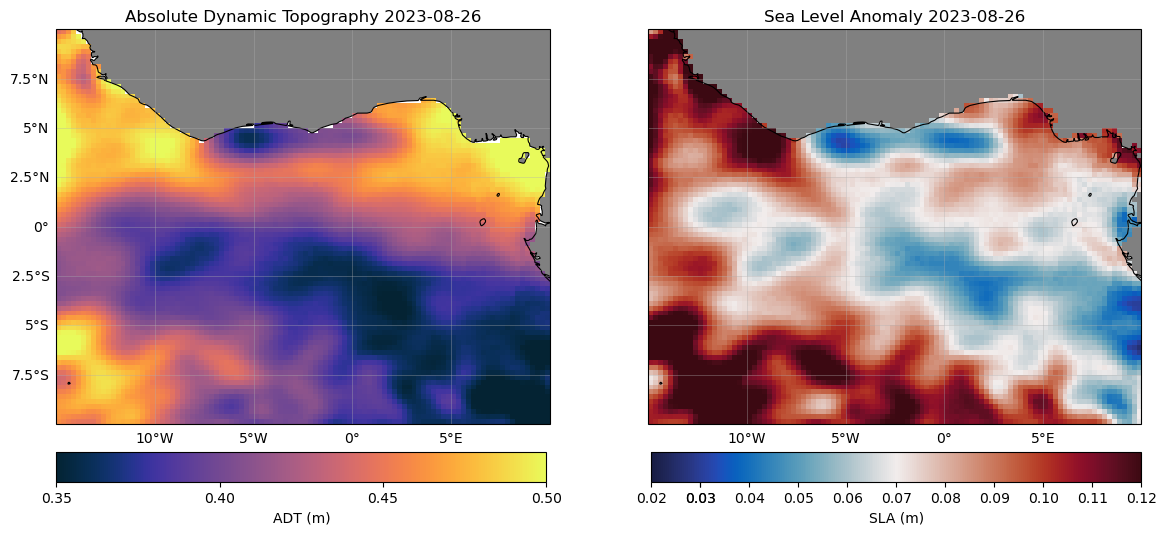

In [4]:
# Sélection des données ADT pour la date spécifique
adt_day = nc_ssh["adt"].sel(time="2023-08-26")

# Sélection des données SLA (Sea Level Anomaly) pour la même date
sla_day = nc_ssh["sla"].sel(time="2023-08-26")

# Conversion du temps en format datetime et formatage en chaîne de caractères
time_ssh = pd.to_datetime(adt_day.time.values).strftime('%Y-%m-%d')

# Définition de la zone géographique à afficher [longitude_min, longitude_max, latitude_min, latitude_max]
extent = [-15, 10, -10, 10]

# Définition de la projection cartographique (PlateCarree pour les coordonnées latitude/longitude)
proj = ccrs.PlateCarree()

# Définition des ticks personnalisés pour la colorbar ADT
tick_adt = [0.35, 0.40, 0.45, 0.5]

# Définition des ticks personnalisés pour la colorbar SLA
tick_sla = [0.02, 0.03, 0.03, 0.04, 0.05, 0.06, 0.07,0.08,0.09,0.1,0.11,0.12]

# Création de la figure avec 2 subplots côte à côte et spécification de la projection
fig, axs = plt.subplots(1, 2, figsize=(14, 10), subplot_kw={"projection": proj})

# =============================================================================
# PREMIÈRE FIGURE - ABSOLUTE DYNAMIC TOPOGRAPHY (ADT)
# =============================================================================

# Affichage des données ADT avec plage de valeurs et colormap spécifiques
im0 = adt_day.plot(ax=axs[0], vmin=0.35, vmax=0.5, transform=proj, cmap=cmocean.cm.thermal,
                   add_colorbar=False)  # Désactivation de la colorbar automatique

# Ajout des lignes côtières avec résolution de 50m et épaisseur de ligne
axs[0].coastlines(resolution='50m', linewidth=0.8)

# Ajout des zones terrestres avec couleur grise
axs[0].add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.5")

# Définition de l'étendue géographique de la carte
axs[0].set_extent(extent)

# Ajout des grilles avec labels sur les axes
gl = axs[0].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, x_inline=False, y_inline=False)

# Masquage des labels sur le bord supérieur
gl.top_labels = False

# Masquage des labels sur le bord droit
gl.right_labels = False

# Titre de la première sous-figure avec date
axs[0].set_title(f"Absolute Dynamic Topography {time_ssh}")

# =============================================================================
# DEUXIÈME FIGURE - SEA LEVEL ANOMALY (SLA)
# =============================================================================

# Affichage des données SLA avec colormap balance (bleu-blanc-rouge)
im1 = sla_day.plot(ax=axs[1],vmin=0.02, vmax=0.12, transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance,
                   add_colorbar=False)  # Désactivation de la colorbar automatique


# Ajout des lignes côtières
axs[1].coastlines(resolution='50m', linewidth=0.8)

# Ajout des zones terrestres
axs[1].add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.5")

# Définition de la même étendue géographique
axs[1].set_extent(extent)

# Ajout des grilles avec labels
gl = axs[1].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, x_inline=False, y_inline=False)

# Masquage des labels supérieurs
gl.top_labels = False

# Masquage des labels droits
gl.right_labels = False
gl.left_labels = False

# Titre de la deuxième sous-figure avec date
axs[1].set_title(f"Sea Level Anomaly {time_ssh}")

# =============================================================================
# CONFIGURATION DES COLORBARS
# =============================================================================

# Création d'un axe pour la colorbar ADT positionné sous la première figure
# [left, bottom, width, height] - left: position horizontale, bottom: position verticale
cb0_ax = fig.add_axes([0.125, 0.26, 0.35, 0.03])

# Ajout de la colorbar ADT dans l'axe créé, orientation horizontale avec ticks personnalisés
cbar0 = fig.colorbar(im0, cax=cb0_ax, orientation='horizontal', ticks=tick_adt)

# Ajout du label pour la colorbar ADT
cbar0.set_label('ADT (m)')

# Création d'un axe pour la colorbar SLA positionné sous la deuxième figure
cb1_ax = fig.add_axes([0.55, 0.26, 0.35, 0.03])

# Ajout de la colorbar SLA dans l'axe créé
cbar1 = fig.colorbar(im1, cax=cb1_ax, orientation='horizontal', ticks=tick_sla)

# Ajout du label pour la colorbar SLA
cbar1.set_label('SLA (m)')

# Ajustement de l'espacement en bas de la figure pour faire place aux colorbars
plt.subplots_adjust(bottom=0.15)

# Affichage de la figure complète
plt.show()

# Ajout d'un point et délimitation d'une region sur la carte #

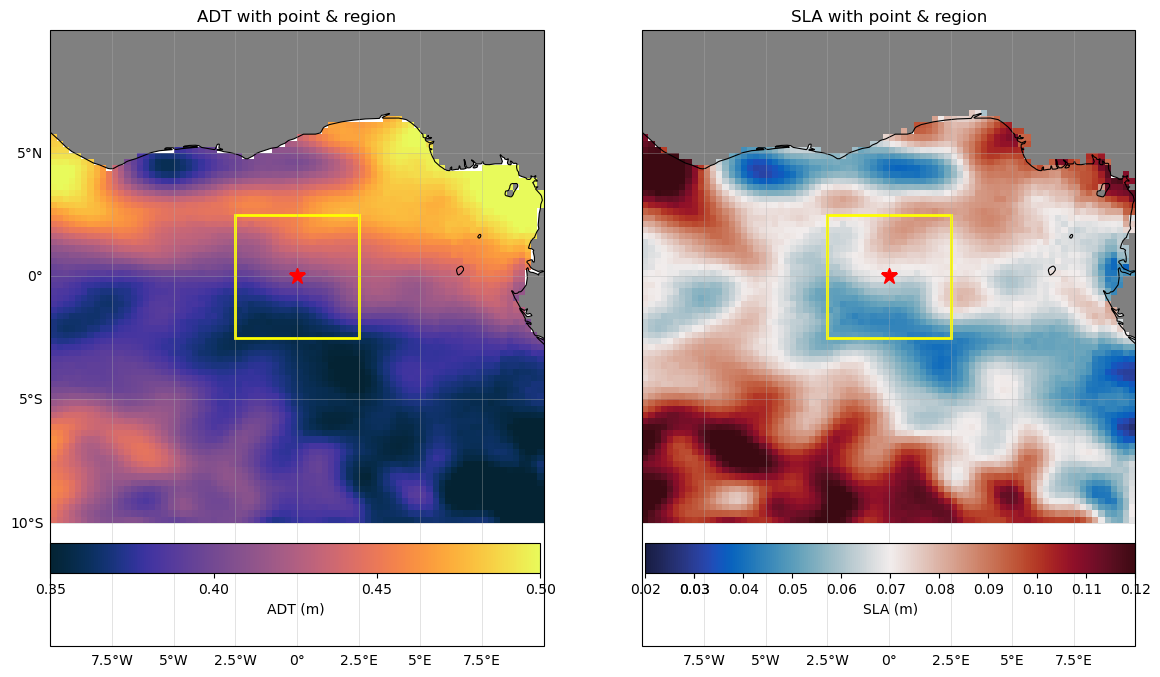

In [5]:
# Sélection des données ADT pour la date spécifique
adt_day = nc_ssh["adt"].sel(time="2023-08-26")

# Sélection des données SLA (Sea Level Anomaly) pour la même date
sla_day = nc_ssh["sla"].sel(time="2023-08-26")

# Conversion du temps en format datetime et formatage en chaîne de caractères
time_ssh = pd.to_datetime(adt_day.time.values).strftime('%Y-%m-%d')

# Point and region definition
pt_lon, pt_lat = 0, 0
lon_min, lon_max = -2.5, 2.5
lat_min, lat_max = -2.5, 2.5

# Définition de la zone géographique à afficher [longitude_min, longitude_max, latitude_min, latitude_max]
extent = [-10, 10, -15, 10]

# Définition de la projection cartographique (PlateCarree pour les coordonnées latitude/longitude)
proj = ccrs.PlateCarree()

# Définition des ticks personnalisés pour la colorbar ADT
tick_adt = [0.35, 0.40, 0.45, 0.5]

# Définition des ticks personnalisés pour la colorbar SLA
tick_sla = [0.02, 0.03, 0.03, 0.04, 0.05, 0.06, 0.07,0.08,0.09,0.1,0.11,0.12]

# Création de la figure avec 2 subplots côte à côte et spécification de la projection
fig, axs = plt.subplots(1, 2, figsize=(14, 10), subplot_kw={"projection": proj})
# =============================================================================
# PREMIÈRE FIGURE - ABSOLUTE DYNAMIC TOPOGRAPHY (ADT)
# =============================================================================

# Affichage des données ADT avec plage de valeurs et colormap spécifiques
im0 = adt_day.plot(ax=axs[0], vmin=0.35, vmax=0.5, transform=proj, cmap=cmocean.cm.thermal,
                   add_colorbar=False)  # Désactivation de la colorbar automatique

# Ajout des lignes côtières avec résolution de 50m et épaisseur de ligne
axs[0].coastlines(resolution='50m', linewidth=0.8)

# Ajout des zones terrestres avec couleur grise
axs[0].add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.5")

# Définition de l'étendue géographique de la carte
axs[0].set_extent(extent)

# Ajout des grilles avec labels sur les axes
gl = axs[0].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, x_inline=False, y_inline=False)

# Masquage des labels sur le bord supérieur
gl.top_labels = False

# Masquage des labels sur le bord droit
gl.right_labels = False

# Ajout  du point point considéré ( en définissant ses carrasteristiques ) la première sous-figure
axs[0].plot(pt_lon, pt_lat, marker="*", color="red", markersize=12, transform=proj)  # ⭐ point

# Delimitation du rectangle définissant la region considéreé et insertion sur la première figure
rect = mpatches.Rectangle((lon_min, lat_min), lon_max-lon_min, lat_max-lat_min,
                          linewidth=2, edgecolor="yellow", facecolor="none", transform=proj)
axs[0].add_patch(rect)

# Titre de la première sous-figure avec date
axs[0].set_title("ADT with point & region")
# =============================================================================
# DEUXIÈME FIGURE - SEA LEVEL ANOMALY (SLA)
# =============================================================================

# Affichage des données SLA avec colormap balance (bleu-blanc-rouge)
im1 = sla_day.plot(ax=axs[1],vmin=0.02, vmax=0.12, transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance,
                   add_colorbar=False)  # Désactivation de la colorbar automatique


# Ajout des lignes côtières
axs[1].coastlines(resolution='50m', linewidth=0.8)

# Ajout des zones terrestres
axs[1].add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.5")

# Définition de la même étendue géographique
axs[1].set_extent(extent)

# Ajout des grilles avec labels
gl = axs[1].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, x_inline=False, y_inline=False)

# Masquage des labels supérieurs
gl.top_labels = False

# Masquage des labels droits
gl.right_labels = False
gl.left_labels = False

# Ajout  du point point considéré ( en définissant ses carrasteristiques ) la deuxième  sous-figure
axs[1].plot(pt_lon, pt_lat, marker="*", color="red", markersize=12, transform=proj)  # ⭐ point

# définition du rectangle correspndant à la region considérée délimitation sur la deuxième  sous-figure
rect = mpatches.Rectangle((lon_min, lat_min), lon_max-lon_min, lat_max-lat_min,
                          linewidth=2, edgecolor="yellow", facecolor="none", transform=proj)
axs[1].add_patch(rect)

# Titre de la deuxième sous-figure avec date
axs[1].set_title("SLA with point & region")

# =============================================================================
# CONFIGURATION DES COLORBARS
# =============================================================================

# Création d'un axe pour la colorbar ADT positionné sous la première figure
# [left, bottom, width, height] - left: position horizontale, bottom: position verticale
cb0_ax = fig.add_axes([0.125, 0.26, 0.35, 0.03])

# Ajout de la colorbar ADT dans l'axe créé, orientation horizontale avec ticks personnalisés
cbar0 = fig.colorbar(im0, cax=cb0_ax, orientation='horizontal', ticks=tick_adt)

# Ajout du label pour la colorbar ADT
cbar0.set_label('ADT (m)')

# Création d'un axe pour la colorbar SLA positionné sous la deuxième figure
cb1_ax = fig.add_axes([0.55, 0.26, 0.35, 0.03])

# Ajout de la colorbar SLA dans l'axe créé
cbar1 = fig.colorbar(im1, cax=cb1_ax, orientation='horizontal', ticks=tick_sla)

# Ajout du label pour la colorbar SLA
cbar1.set_label('SLA (m)')

# Affichage de la figure complète
plt.show()



## Serie Temporelle à un point  et serie temporelle de la moyenne spatiale dans une region ##  

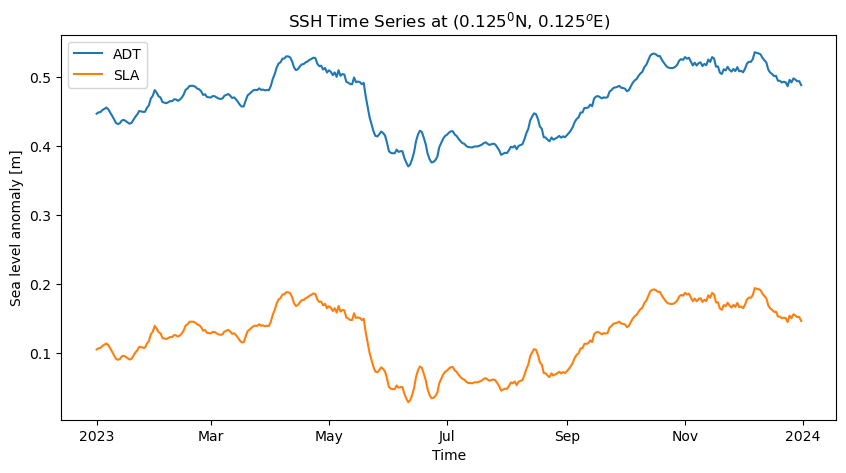

In [6]:
#  Serie temporelle à un point de la zone (ADT & SLA)
adt_point = nc_ssh["adt"].sel(longitude=pt_lon, latitude=pt_lat, method="nearest")
sla_point = nc_ssh["sla"].sel(longitude=pt_lon, latitude=pt_lat, method="nearest")

plt.figure(figsize=(10,5))
adt_point.plot(label="ADT")
sla_point.plot(label="SLA")
plt.legend()
plt.title(f"SSH Time Series at ({adt_point.latitude.values}$^0$N, {adt_point.longitude.values}$ ^o$E)")
plt.show()

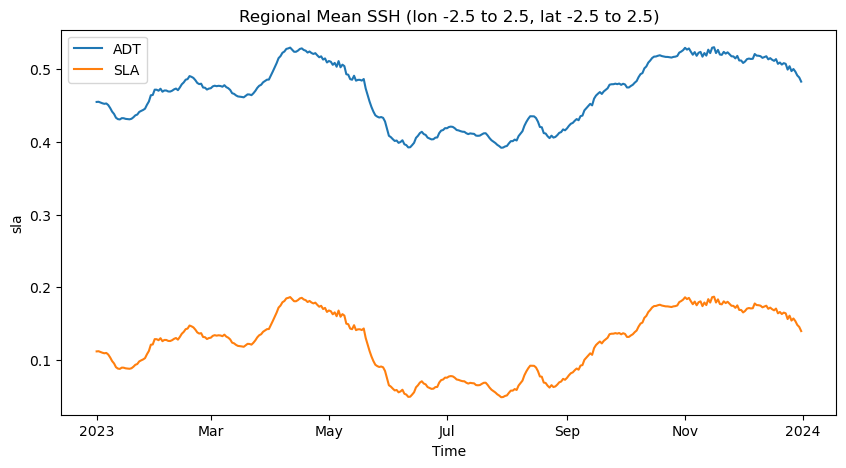

In [7]:
# série temporelle de la moyenne spatiales dans une region (ADT & SLA)
adt_reg = nc_ssh["adt"].sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max)).mean(dim=["longitude","latitude"])
sla_reg = nc_ssh["sla"].sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max)).mean(dim=["longitude","latitude"])

plt.figure(figsize=(10,5))
adt_reg.plot(label="ADT")
sla_reg.plot(label="SLA")
plt.legend()
plt.title(f"Regional Mean SSH (lon {lon_min} to {lon_max}, lat {lat_min} to {lat_max})")
plt.show()

## Distribution spatiales des anomalies temporelles d'ADT et de SLA ##

In [8]:
# Calcul des anomalies (en utilisant la fonction "mean" pour calculer la moyenne)
adt_ano = nc_ssh["adt"] - nc_ssh["adt"].mean(dim="time")
sla_ano = nc_ssh["sla"] - nc_ssh["sla"].mean(dim="time")
print(adt_ano)
print(sla_ano)

<xarray.DataArray 'adt' (time: 365, latitude: 80, longitude: 100)> Size: 12MB
array([[[-0.01965874, -0.02474269, -0.03088048, ...,  0.00463811,
         -0.00274387, -0.0075469 ],
        [-0.01805496, -0.02612397, -0.03212163, ...,  0.0040192 ,
         -0.00222033, -0.00561222],
        [-0.01763764, -0.02538043, -0.03254664, ...,  0.00133279,
         -0.0035463 , -0.00785884],
        ...,
        [-0.03252429, -0.03129297, -0.02523875, ...,         nan,
                 nan,         nan],
        [-0.03677642, -0.04055387, -0.03324485, ...,         nan,
                 nan,         nan],
        [-0.04017243, -0.04455408, -0.03698546, ...,         nan,
                 nan,         nan]],

       [[-0.02115875, -0.02744269, -0.03208047, ...,  0.00133809,
         -0.00544384, -0.00854692],
        [-0.01935494, -0.02792397, -0.03522164, ...,  0.00191921,
         -0.00312033, -0.00541222],
        [-0.01903763, -0.02778044, -0.03484663, ...,  0.00063279,
         -0.00414631, -0.

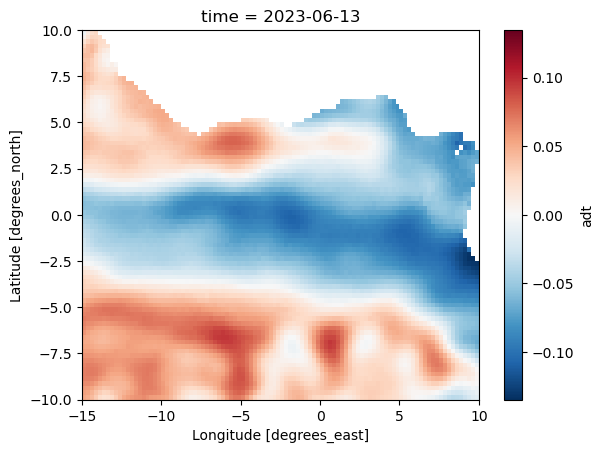

In [9]:
adt_ano_jour = adt_ano.sel(time="2023-06-13")
adt_ano_jour.plot()

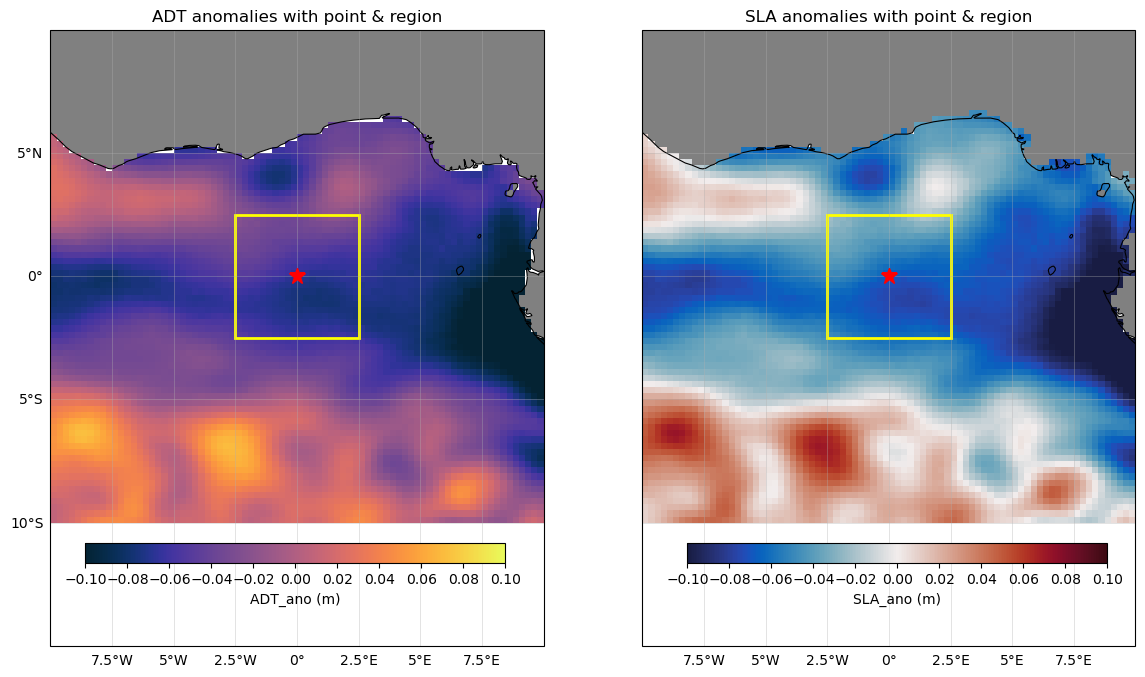

In [11]:
# Sélection des données ADT pour la date spécifique
adt_ano_day = adt_ano.sel(time="2023-07-15")

# Sélection des données SLA (Sea Level Anomaly) pour la même date
sla_ano_day = sla_ano.sel(time="2023-07-15")

# Conversion du temps en format datetime et formatage en chaîne de caractères
time_ssh = pd.to_datetime(adt_day.time.values).strftime('%Y-%m-%d')

# Point and region definition
pt_lon, pt_lat = 0, 0
lon_min, lon_max = -2.5, 2.5
lat_min, lat_max = -2.5, 2.5

# Définition de la zone géographique à afficher [longitude_min, longitude_max, latitude_min, latitude_max]
extent = [-10, 10, -15, 10]

# Définition de la projection cartographique (PlateCarree pour les coordonnées latitude/longitude)
proj = ccrs.PlateCarree()

# Définition des ticks personnalisés pour la colorbar ADT
tick_adt_ano_day = [-0.1 , -0.08, -0.06, -0.04, -0.02 , 0.  ,  0.02,  0.04 , 0.06,  0.08 , 0.1 ]

# Définition des ticks personnalisés pour la colorbar SLA
tick_sla_ano_day = [-0.1 , -0.08, -0.06, -0.04, -0.02 , 0.  ,  0.02,  0.04 , 0.06,  0.08 , 0.1 ]

# Création de la figure avec 2 subplots côte à côte et spécification de la projection
fig, axs = plt.subplots(1, 2, figsize=(14, 10), subplot_kw={"projection": proj})
# =============================================================================
# PREMIÈRE FIGURE - ABSOLUTE DYNAMIC TOPOGRAPHY anomalies ( ADT_ano)
# =============================================================================

# Affichage des données des anomalies de l'ADT avec plage de valeurs et colormap spécifiques
im0 = adt_ano_day.plot(ax=axs[0], vmin= -0.1, vmax=0.1, transform=proj, cmap=cmocean.cm.thermal,
                   add_colorbar=False)  # Désactivation de la colorbar automatique

# Ajout des lignes côtières avec résolution de 50m et épaisseur de ligne
axs[0].coastlines(resolution='50m', linewidth=0.8)

# Ajout des zones terrestres avec couleur grise
axs[0].add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.5")

# Définition de l'étendue géographique de la carte
axs[0].set_extent(extent)

# Ajout des grilles avec labels sur les axes
gl = axs[0].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, x_inline=False, y_inline=False)

# Masquage des labels sur le bord supérieur
gl.top_labels = False

# Masquage des labels sur le bord droit
gl.right_labels = False

# Ajout  du point point considéré ( en définissant ses carrasteristiques ) la première sous-figure
axs[0].plot(pt_lon, pt_lat, marker="*", color="red", markersize=12, transform=proj)  # ⭐ point

# Delimitation du rectangle définissant la region considéreé et insertion sur la première figure
rect = mpatches.Rectangle((lon_min, lat_min), lon_max-lon_min, lat_max-lat_min,
                          linewidth=2, edgecolor="yellow", facecolor="none", transform=proj)
axs[0].add_patch(rect)

# Titre de la première sous-figure avec date
axs[0].set_title("ADT anomalies with point & region")
# =============================================================================
# DEUXIÈME FIGURE - SEA LEVEL ANOMALY anomalies (SLA_ano)
# =============================================================================

# Affichage des données anomalies de la SLA avec colormap balance (bleu-blanc-rouge)
im1 = sla_ano_day.plot(ax=axs[1],vmin=-0.1, vmax=0.1, transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance,
                   add_colorbar=False)  # Désactivation de la colorbar automatique


# Ajout des lignes côtières
axs[1].coastlines(resolution='50m', linewidth=0.8)

# Ajout des zones terrestres
axs[1].add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.5")

# Définition de la même étendue géographique
axs[1].set_extent(extent)

# Ajout des grilles avec labels
gl = axs[1].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, x_inline=False, y_inline=False)

# Masquage des labels supérieurs
gl.top_labels = False

# Masquage des labels droits
gl.right_labels = False
gl.left_labels = False

# Ajout  du point point considéré ( en définissant ses carrasteristiques ) la deuxième  sous-figure
axs[1].plot(pt_lon, pt_lat, marker="*", color="red", markersize=12, transform=proj)  # ⭐ point

# définition du rectangle correspndant à la region considérée délimitation sur la deuxième  sous-figure
rect = mpatches.Rectangle((lon_min, lat_min), lon_max-lon_min, lat_max-lat_min,
                          linewidth=2, edgecolor="yellow", facecolor="none", transform=proj)
axs[1].add_patch(rect)

# Titre de la deuxième sous-figure avec date
axs[1].set_title("SLA anomalies with point & region")

# =============================================================================
# CONFIGURATION DES COLORBARS
# =============================================================================

# Création d'un axe pour la colorbar ADT positionné sous la première figure
# [left, bottom, width, height] - left: position horizontale, bottom: position verticale
cb0_ax = fig.add_axes([0.15, 0.27, 0.3, 0.02])

# Ajout de la colorbar ADT dans l'axe créé, orientation horizontale avec ticks personnalisés
cbar0 = fig.colorbar(im0, cax=cb0_ax, orientation='horizontal', ticks=tick_adt_ano_day)

# Ajout du label pour la colorbar ADT_ano
cbar0.set_label('ADT_ano (m)')

# Création d'un axe pour la colorbar SLA positionné sous la deuxième figure
cb1_ax = fig.add_axes([0.58, 0.27, 0.3, 0.02])

# Ajout de la colorbar SLA dans l'axe créé
cbar1 = fig.colorbar(im1, cax=cb1_ax, orientation='horizontal', ticks=tick_sla_ano_day)

# Ajout du label pour la colorbar SLA_ano
cbar1.set_label('SLA_ano (m)')

# Affichage de la figure complète
plt.show()



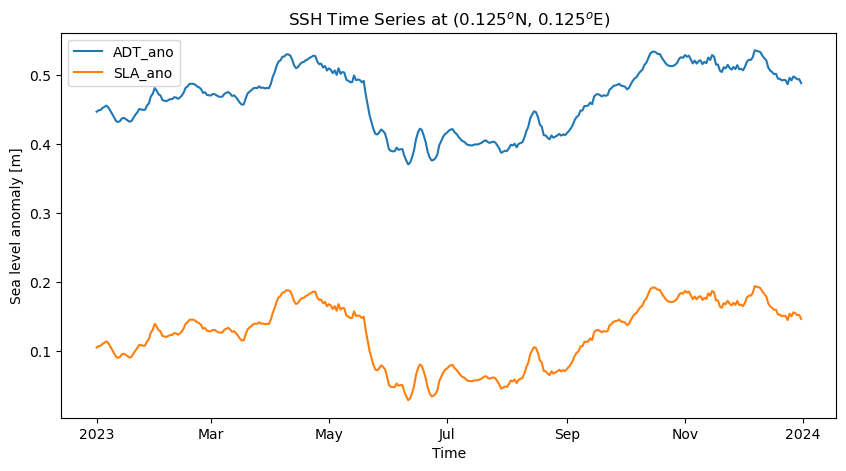

In [12]:
# Point time series (both ADT & SLA)
adt_point_ano = adt_ano.sel(longitude=pt_lon, latitude=pt_lat, method="nearest")
sla_point_ano = sla_ano.sel(longitude=pt_lon, latitude=pt_lat, method="nearest")

plt.figure(figsize=(10,5))
adt_point.plot(label="ADT_ano")
sla_point.plot(label="SLA_ano")
plt.legend()
plt.title(f"SSH Time Series at ({adt_point.latitude.values}$^o$N, {adt_point.longitude.values}$^o$E)")
plt.show()

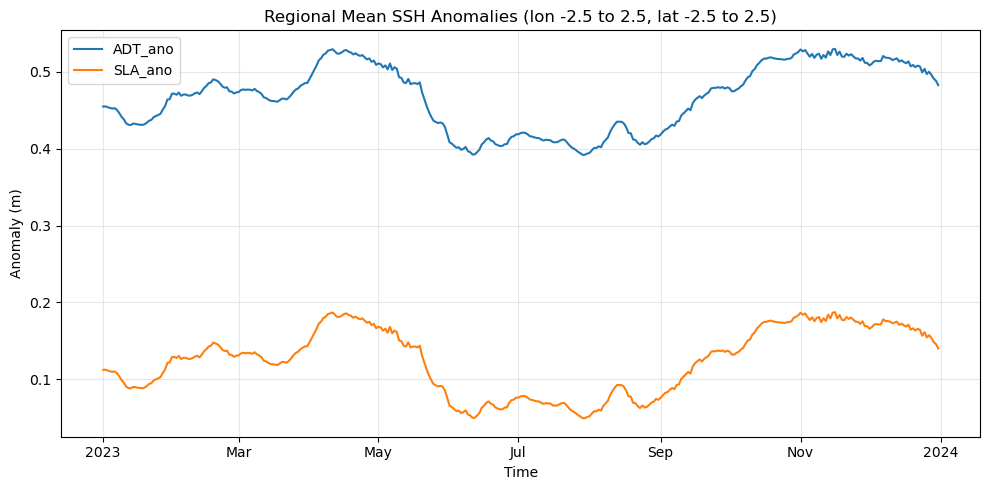

In [22]:
# Regional mean time series (both ADT & SLA)
adt_reg_ano = adt_ano.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max)).mean(dim=["longitude","latitude"])
sla_reg_ano = sla_ano.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max)).mean(dim=["longitude","latitude"])

plt.figure(figsize=(10,5))
adt_reg.plot(label="ADT_ano")
sla_reg.plot(label="SLA_ano")
plt.legend()
plt.title(f"Regional Mean SSH Anomalies (lon {lon_min} to {lon_max}, lat {lat_min} to {lat_max})")
plt.ylabel("Anomaly (m)")
plt.xlabel("Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()